In [11]:
import tensorflow as tf
import pandas as pd


def read_tensorboard_data(log_dir):
    data = []
    for event_file in tf.io.gfile.glob(f"{log_dir}/events.out.tfevents.*"):
        for event in tf.compat.v1.train.summary_iterator(event_file):
            for value in event.summary.value:
                data.append({"step": event.step, "tag": value.tag, "value": value.simple_value})
    return pd.DataFrame(data)


# Replace with your log directory
log_dir = "./runs/Sep13_15-54-54_ds-turing02"
df_1 = read_tensorboard_data(log_dir)
df_1 = df_1[df_1["tag"] == "step/train_loss"]

In [12]:
df_2 = read_tensorboard_data("./runs/Sep16_22-52-18_ds-turing02")
df_2 = df_2[df_2["tag"] == "step/train_loss"]

In [13]:
df_1

,step,tag,value
0,0,step/train_loss,1748.338379
2,1,step/train_loss,2006.541260
4,2,step/train_loss,1860.332153
6,3,step/train_loss,1769.222900
8,4,step/train_loss,1615.568726
...,...,...,...
10002,4995,step/train_loss,456.397217
10004,4996,step/train_loss,449.486359
10006,4997,step/train_loss,269.078003
10008,4998,step/train_loss,476.461761


In [14]:
df_2

,step,tag,value
0,0,step/train_loss,679.152527
2,1,step/train_loss,583.049683
4,2,step/train_loss,839.347717
6,3,step/train_loss,590.620239
8,4,step/train_loss,563.220520
...,...,...,...
6411,3204,step/train_loss,700.367310
6413,3205,step/train_loss,786.646545
6415,3206,step/train_loss,776.750000
6417,3207,step/train_loss,1111.460083


In [15]:
import numpy as np

new_steps = np.arange(5000, 5000 + len(df_2))

# Assign the new values to the 'step' column
df_2["step"] = new_steps

In [16]:
df_2

,step,tag,value
0,5000,step/train_loss,679.152527
2,5001,step/train_loss,583.049683
4,5002,step/train_loss,839.347717
6,5003,step/train_loss,590.620239
8,5004,step/train_loss,563.220520
...,...,...,...
6411,8204,step/train_loss,700.367310
6413,8205,step/train_loss,786.646545
6415,8206,step/train_loss,776.750000
6417,8207,step/train_loss,1111.460083


In [17]:
all_step_losses = pd.concat([df_1, df_2])

In [20]:
import matplotlib.pyplot as plt

In [18]:
import numpy as np


def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size), "valid") / window_size


x = np.array(all_step_losses["step"])
y = np.array(all_step_losses["value"])

window_size = 20  # Adjust this value to control the smoothing level
y_smoothed = moving_average(y, window_size)
x_smoothed = x[window_size - 1 :]

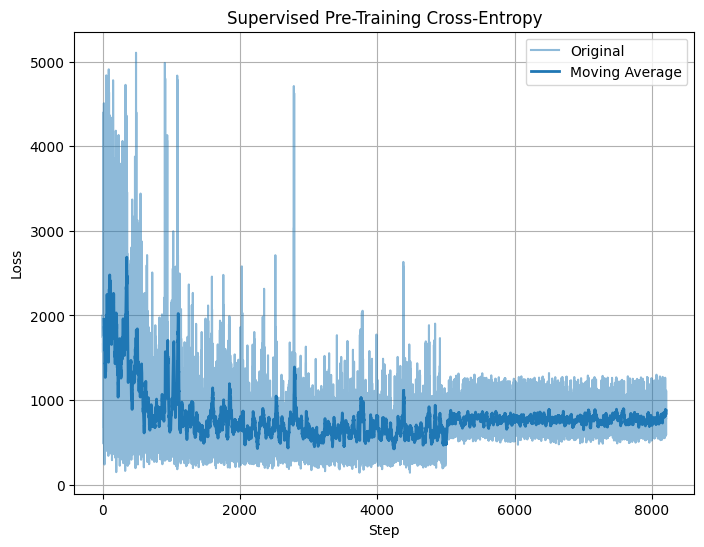

In [21]:
plt.figure(figsize=(8, 6))
plt.plot(x, y, label="Original", alpha=0.5, color="#1f77b4")
plt.plot(x_smoothed, y_smoothed, label="Moving Average", linewidth=2, color="#1f77b4")
plt.title("Supervised Pre-Training Cross-Entropy")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("Supervised Pre-training cross-entropy per step loss.pdf", format="pdf", bbox_inches="tight")